## **Machine Learning-Based Heart Disease Prediction System**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
with zipfile.ZipFile('/content/drive/MyDrive/archive (4).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/heart_data')

2. Data Exploration:
In this step, the structure of the dataset was examined, including the number of samples, features, and data types.

In [ ]:
!ls /content/heart_data

heart_disease_cleveland.csv  heart_disease_combined.csv


In [ ]:
import pandas as pd

df = pd.read_csv('/content/heart_data/heart_disease_combined.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,source
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,cleveland


In [ ]:
df.shape

(920, 15)

In [ ]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target', 'source'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalach,55
exang,55
oldpeak,62


In [ ]:
df.dtypes

,0
age,float64
sex,float64
cp,float64
trestbps,float64
chol,float64
fbs,float64
restecg,float64
thalach,float64
exang,float64
oldpeak,float64


In [ ]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target', 'source'],
      dtype='object')

4. Feature Selection:
The input features (X) and the target variable (y) were defined. The target represents whether the patient has heart disease or not.

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

3. Data Cleaning:
In this step, missing values were identified and handled to ensure data quality before model training.

In [ ]:
from sklearn.impute import SimpleImputer
import pandas as pd

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

if len(numeric_cols) > 0:
    num_imputer = SimpleImputer(strategy='median')
    X[numeric_cols] = num_imputer.fit_transform(X[numeric_cols])

if len(categorical_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

X.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
X = pd.get_dummies(X, drop_first=True)
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,source_hungarian,source_switzerland,source_va
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,False,False,False
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,False,False,False
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,False,False,False
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,False,False,False
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,False,False,False


In [ ]:
y.value_counts()

,count
target,
1,509
0,411


6. Data Splitting:
The dataset was split into training and testing sets to evaluate model performance on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

6. Data Scaling:
In this step, feature scaling was applied to normalize the data and improve model performance.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

7. Model Training:
In this step, a Logistic Regression model was trained on the dataset to classify patients based on heart disease risk.

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [ ]:
y_pred = model.predict(X_test)

8. Model Evaluation:
In this step, the trained model was evaluated using performance metrics such as accuracy, confusion matrix, and classification report to assess how well the model predicts heart disease.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8315217391304348

Confusion Matrix:
 [[65 17]
 [14 88]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.79      0.81        82
           1       0.84      0.86      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184



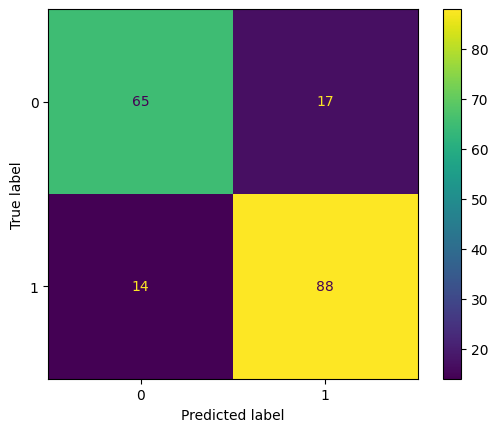

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=2000)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_log = log_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.8315217391304348
[[65 17]
 [14 88]]
              precision    recall  f1-score   support

           0       0.82      0.79      0.81        82
           1       0.84      0.86      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184



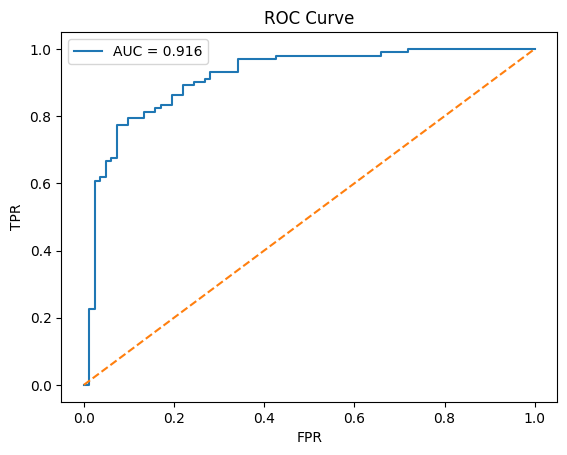

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = log_model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

9. Model Training (Random Forest):
A Random Forest model was trained to compare performance with Logistic Regression.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

10. Model Evaluation (Random Forest):
The Random Forest model was evaluated using accuracy, confusion matrix, and classification report to assess its performance.

In [ ]:
y_pred_rf = rf_model.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

RF Accuracy: 0.842391304347826
[[66 16]
 [13 89]]


11. ROC Curve Analysis (Random Forest):
In this step, the ROC curve was used to evaluate the performance of the Random Forest model. The AUC score indicates how well the model distinguishes between patients with and without heart disease.

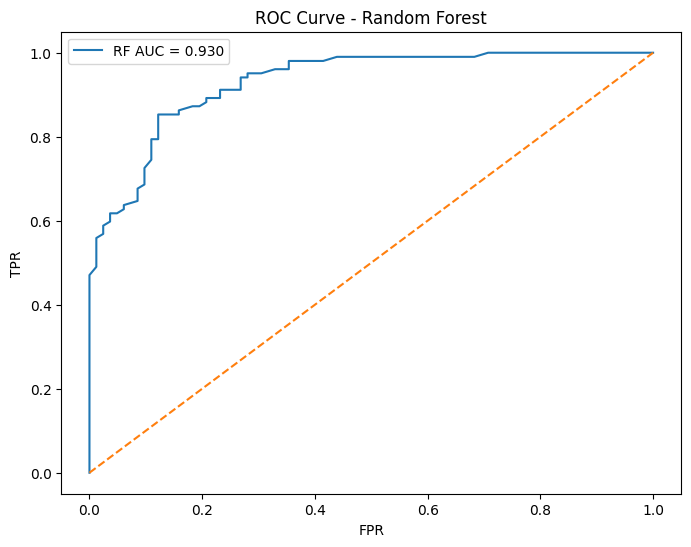

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label=f"RF AUC = {auc_rf:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

"12. ROC Curve Comparison: In this step, we compared the ROC curves and AUC scores of both the Logistic Regression model and the Random Forest model. This comparison helps visualize which model provides better discrimination between positive and negative cases."

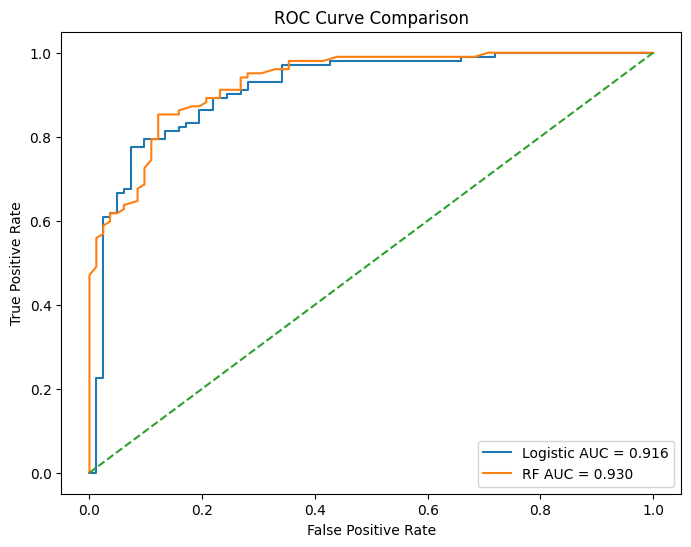

In [ ]:
# مقارنة ROC للـ Logistic والـ Random Forest
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC للـ Logistic Regression
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = roc_auc_score(y_test, y_prob_log)

# ROC للـ Random Forest
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

# الرسم
plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label=f"Logistic AUC = {auc_log:.3f}")
plt.plot(fpr_rf, tpr_rf, label=f"RF AUC = {auc_rf:.3f}")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
sample = X_test[[0]]
sample

array([[-0.49051306,  0.5249412 ,  0.81267098, -0.11641087,  0.0414897 ,
        -0.41469811, -0.76013746,  1.27901502, -0.76787553, -0.80788285,
         0.31816177, -0.35792038,  0.3087147 ,  1.4832397 , -0.38497523,
        -0.53335515]])

In [ ]:
pred = log_model.predict(scaler.transform(sample))
prob = log_model.predict_proba(scaler.transform(sample))[:,1]

print("Prediction:", pred[0])
print("Probability:", prob[0])

Prediction: 0
Probability: 0.30252967716147017


In [ ]:
pred_rf = rf_model.predict(sample)
prob_rf = rf_model.predict_proba(sample)[:,1]

print("Prediction:", pred_rf[0])
print("Probability:", prob_rf[0])

Prediction: 0
Probability: 0.455


In [ ]:
if pred_rf[0] == 1:
    print("⚠️ Patient is likely to have heart disease")
else:
    print("✅ Patient is unlikely to have heart disease")

✅ Patient is unlikely to have heart disease



“After training the model, we can input a new patient's clinical data, and the model predicts whether the patient is at risk of heart disease based on learned patterns.”

In [ ]:
Prediction: 0
Probability: 0.30

In [ ]:
Prediction: 0
Probability: 0.45

In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
2,cp,0.145817
4,chol,0.132419
7,thalach,0.117361
0,age,0.114003
9,oldpeak,0.101655
8,exang,0.079958
3,trestbps,0.072104
12,thal,0.046721
1,sex,0.034716
14,source_switzerland,0.027361


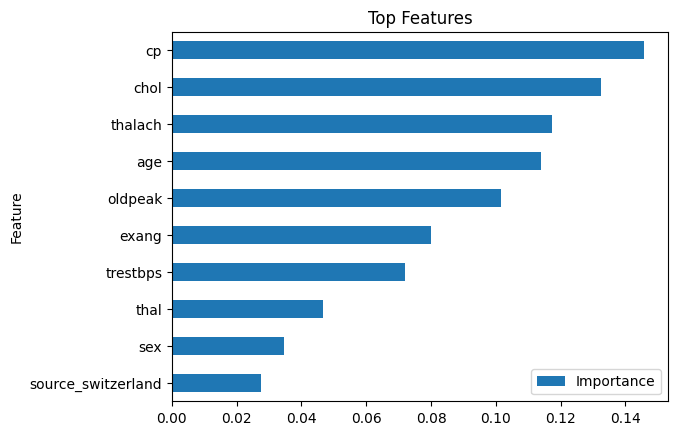

In [ ]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(kind='barh', x='Feature', y='Importance')
plt.gca().invert_yaxis()
plt.title("Top Features")
plt.show()

13. Conclusion:
In this project, two machine learning models (Logistic Regression and Random Forest) were developed to predict heart disease using clinical data. Both models were evaluated using accuracy, confusion matrix, and ROC analysis. The Random Forest model showed slightly better performance based on AUC score. This demonstrates that machine learning can effectively support early detection of heart disease and assist in clinical decision-making.
Future Work:
Further improvements could include using more advanced models and larger datasets to enhance prediction accuracy.
